In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from numpy.fft import ifft, fftshift, fftfreq

# function to scale df or numpy array y-axis between 0 and 1
# takes np.array or pd.DataFrame as input
def scale_y_axis(data):
    data = np.array(data)
    return (data - np.min(data)) / (np.max(data) - np.min(data))
    
    

In [3]:
# Load CSV data
df = pd.read_csv("amplifier_spectrum.csv")  # Replace with your filename


df['Intensity'] = scale_y_axis(df['Intensity'])


# plt.plot(df['Wavelength(nm)'], df['Intensity'], lw=1.5)
# plt.title("Mean BK7 Spectrum")
# plt.xlabel("Wavelength (nm)")
# plt.ylabel("Intensity")
# plt.grid(True)
# plt.tight_layout()
# plt.show()



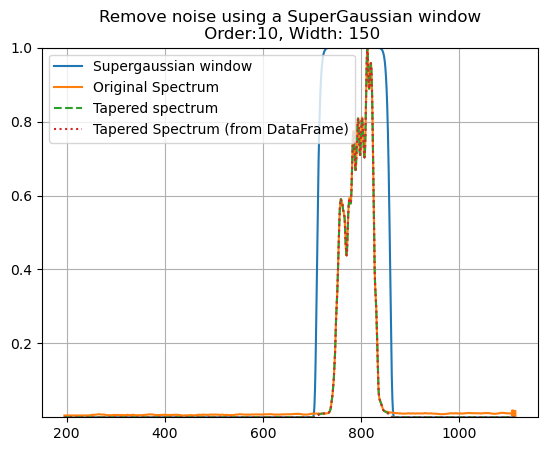

In [4]:
def supergaussian(x, center, width, order, amplitude=1):
    return amplitude * np.exp(-((x - center) / (width / 2)) ** (2 * order))


x_nm = df['Wavelength(nm)'].values
y = df['Intensity'].values

center=785
width=150
order=10 # definition of the supergaussian

supergauss = supergaussian(x_nm, center, width, order)
tapered = y * supergauss



df['Intensity'] = tapered # overwrite the intensity with the tapered spectrum

plt.plot(x_nm, supergauss, label="Supergaussian window")
plt.plot(x_nm, y, label="Original Spectrum")
plt.plot(x_nm, tapered, label = "Tapered spectrum", linestyle="--")

plt.plot(df['Wavelength(nm)'], df['Intensity'], label="Tapered Spectrum (from DataFrame)", linestyle=":")
plt.grid(1)
# plt.yscale("log")
plt.ylim(1e-4, 1)
plt.title(f"Remove noise using a SuperGaussian window\n Order:{order}, Width: {width}")
plt.legend()



/home/soumyajeet/miniconda3/envs/computational/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/soumyajeet/miniconda3/envs/computational/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


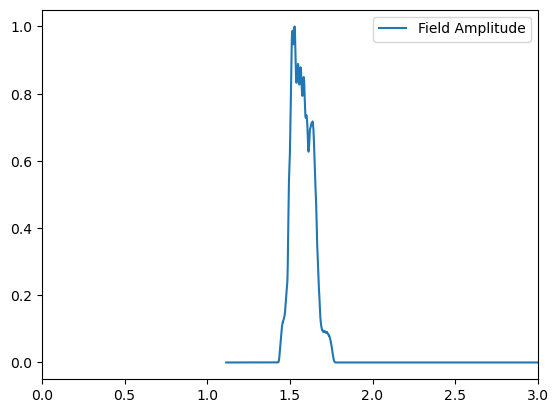

In [5]:
# Convert wavelength (nm) to frequency (Hz)
c = 3e8  # Speed of light in m/s
wavelength_m = df['Wavelength(nm)'] * 1e-9  # Convert nm to meters
frequency_hz = c / wavelength_m  # Frequency in Hz

# Apply Jacobian correction: I(nu) = I(lambda) * (lambda^2 / c)
# Intensity must be adjusted to conserve energy
intensity_corrected = df['Intensity'] * (wavelength_m**2 / c)
intensity_corrected = scale_y_axis(intensity_corrected)  # Scale to [0, 1] for visualization



# Create frequency domain dataframe and sort by increasing frequency
df_freq = pd.DataFrame({
    'Frequency(Hz)': frequency_hz,
    'Corrected Intensity': intensity_corrected
}).sort_values(by='Frequency(Hz)')


# convert intensity to field amplitude
# Field amplitude is the square root of intensity
field_amplitude = np.sqrt(df_freq['Corrected Intensity']).astype(np.complex128)
frequency = df_freq['Frequency(Hz)'].values



plt.plot(frequency * 6.63e-34/1.6e-19, field_amplitude, label="Field Amplitude", lw=1.5)
plt.xlim(0, 3)
# plt.plot(frequency, df_freq['Corrected Intensity'], label="Intensity", lw=1.5, linestyle="--")
plt.legend()

In [6]:
# Determine the minimum frequency in the current spectrum
min_freq = frequency.min()

# Generate a frequency array from 0 to just below the minimum frequency
padding_freq = np.linspace(0, min_freq*1, 500)  # 500 points for smooth padding
padding_field_amplitude = np.zeros_like(padding_freq)


# plt.plot(padding_freq, padding_field_amplitude, label="Padding", marker='*', color='red', lw = 2)
# plt.plot(frequency, field_amplitude, label="Field Amplitude", marker="o" ,lw=2)


# concatenate padding frequency with frequency
extended_freq = np.concatenate((padding_freq[:-1], frequency))
extended_field = np.concatenate((padding_field_amplitude[:-1], field_amplitude))

# plt.plot(extended_freq, extended_field, label="Extended Field Amplitude", lw=0.5, color='black')
# plt.legend()
# plt.xlim(0.268e15, 0.27000e15)  # Adjust x-axis limits to focus on the region of interest
# plt.ylim(-0.001, 0.005)

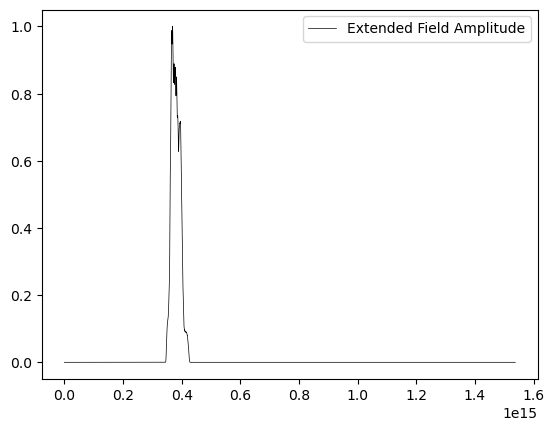

In [7]:
# this part is to increase the temporal resolution
plt.plot(extended_freq, extended_field, label="Extended Field Amplitude", lw=0.5, color='black')
plt.legend()

max_freq = extended_freq.max()

padding_freq = np.linspace(0, min_freq*1, 500)  # 500 points for smooth padding
padding_field_amplitude = np.zeros_like(padding_freq)
length_before_padding = len(extended_freq)
padding_factor = 0

zero_padding_freq = np.linspace(max_freq,
                                max_freq * padding_factor, 
                                length_before_padding * padding_factor)  
zero_padding_field_amplitude = np.zeros_like(zero_padding_freq)


extended_freq1 = np.concatenate((extended_freq.copy(), zero_padding_freq[1:]))
extended_field1 = np.concatenate((extended_field.copy(), zero_padding_field_amplitude[1:]))

# plt.plot(extended_freq, extended_field, label="Extended Field", lw=0.5, marker="o", color='black')
# plt.plot(zero_padding_freq, zero_padding_field_amplitude, label="Zero Padding", marker='*', color='red', lw = 2)
# plt.xlim(1.53e15, 1.54e15)
# plt.legend()
# plt.ylim(-0.001, 0.005)




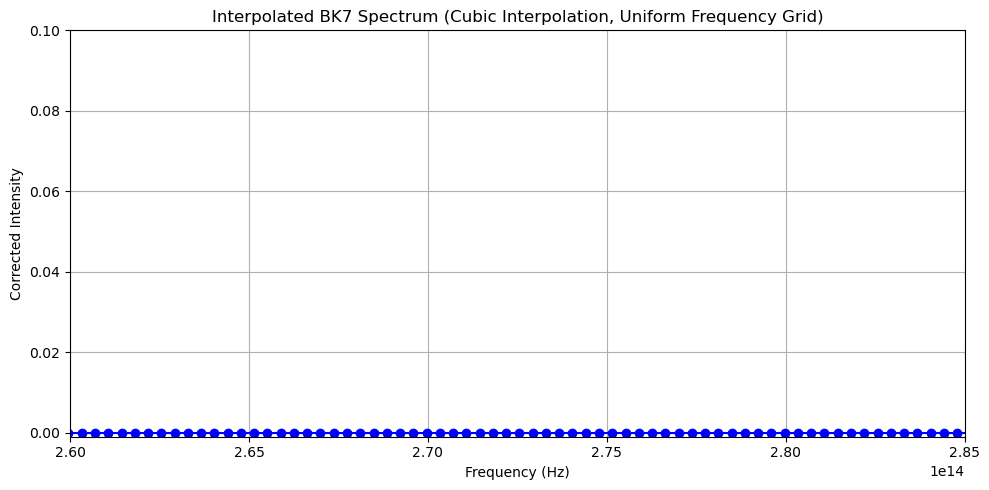

In [8]:
from scipy.interpolate import interp1d


# Extract frequency and intensity arrays
freq = extended_freq1.copy()
field = extended_field1.copy()

# Define uniformly spaced frequency grid
uniform_freq = np.linspace(freq.min(), freq.max(), len(freq))

# Perform cubic interpolation
cubic_interp = interp1d(freq, field, kind='cubic')
uniform_field = cubic_interp(uniform_freq)

# Create interpolated DataFrame
df_uniform = pd.DataFrame({
    'Frequency(Hz)': uniform_freq,
    'Corrected Field': uniform_field
})

# Plot the interpolated spectrum
plt.figure(figsize=(10, 5))
plt.plot(df_uniform['Frequency(Hz)'], df_uniform['Corrected Field'], lw=1.5, marker='o', color='blue', label='Interpolated Spectrum (Cubic)')
plt.title("Interpolated BK7 Spectrum (Cubic Interpolation, Uniform Frequency Grid)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Corrected Intensity")
plt.grid(True)
plt.xlim(0.260e15, 0.2850e15)  # Adjust x-axis limits to focus on the region of interest
plt.ylim(-0.001, 0.1)
plt.tight_layout()
plt.show()


/tmp/ipykernel_62625/3693614577.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  y = np.asarray(y, dtype=np.float64)


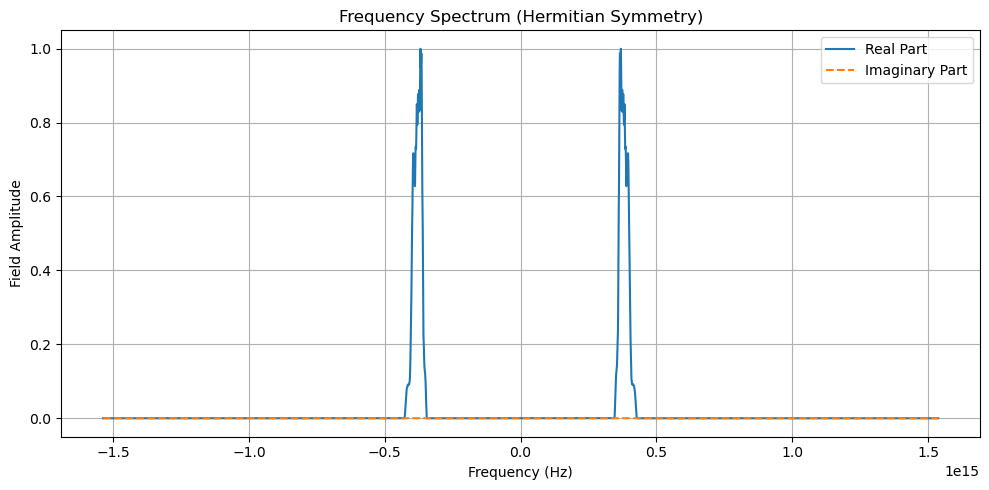

In [9]:
def mirror_frequency_axis(x, y):
    """
    Create a mirrored frequency axis and spectrum for FFT.

    Parameters:
        x (np.ndarray): Frequency array (positive only, uniformly spaced).
        y (np.ndarray): Intensity or field array.

    Returns:
        x_mirrored (np.ndarray): Symmetric frequency array (-f_max to +f_max).
        y_mirrored (np.ndarray): Hermitian-symmetric spectrum (conj mirror of y).
    """
    
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    
    if len(x) != len(y):
        raise ValueError("x and y must be the same length.")
    if not np.allclose(np.diff(x), np.diff(x)[0]):
        raise ValueError("Frequency axis must be uniformly spaced.")

    # Skip the DC term to avoid double-counting zero
    x_neg = -x[::-1][1:]
    y_neg = np.conj(y[::-1][1:])  # Hermitian symmetry

    x_mirrored = np.concatenate((x_neg, x))
    y_mirrored = np.concatenate((y_neg, y))

    return x_mirrored, y_mirrored

frequency_mirrored, field_mirrored = mirror_frequency_axis(uniform_freq, uniform_field)
field_mirrored = field_mirrored.astype(np.complex128)  # Construct real field spectrum (zero phase)

field_mirrored = field_mirrored.astype(np.complex128)  # Construct real field spectrum (zero phase)

plt.figure(figsize=(10, 5))
plt.plot(frequency_mirrored, field_mirrored.real, lw=1.5)
plt.plot(frequency_mirrored, field_mirrored.imag, lw=1.5, ls='--')
plt.title("Frequency Spectrum (Hermitian Symmetry)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Field Amplitude")
plt.grid(True)
plt.legend(['Real Part', 'Imaginary Part'])
plt.tight_layout()
plt.show()



In [10]:


frequency_ordered = np.fft.ifftshift(frequency_mirrored) # this is coefficients in the correct order for ifft, STRICTLY as they are obtained due from the FFT algorithm
# This is NOT FOR VISUALIZATION !!!

field_ordered = np.fft.ifftshift(field_mirrored)


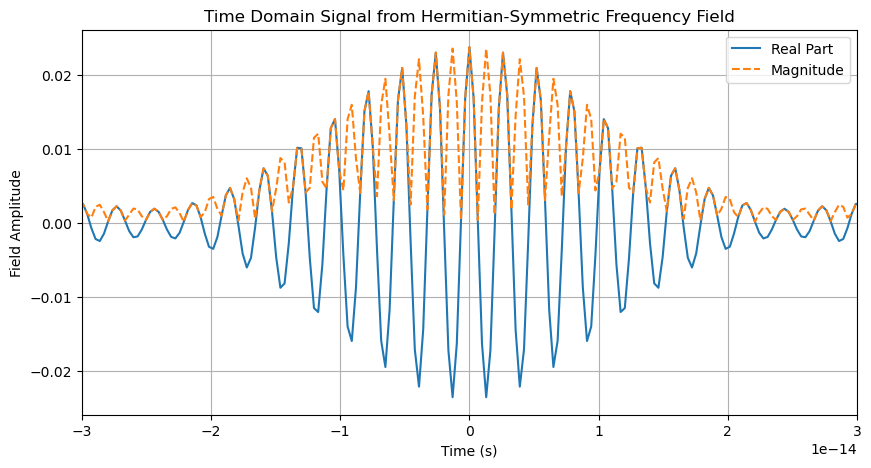

In [11]:
# Step 1: Reorder frequency components so 0 Hz is at index 0
field_ordered = np.fft.ifftshift(field_mirrored)

# Step 2: IFFT to time domain (complex signal)
field_time = np.fft.ifft(field_ordered)

# Step 3: Create time axis
df = frequency_mirrored[1] - frequency_mirrored[0]  # frequency resolution
T = 1 / df                                          # total time span
N = len(field_mirrored)                             # number of points
dt = T / N                                          # time resolution
time = np.fft.fftshift(np.fft.fftfreq(N, d=df))     # centered time axis
field_time_shifted = np.fft.fftshift(field_time)    # shift signal for plotting

# Step 4: Plot time-domain field
plt.figure(figsize=(10, 5))
plt.plot(time, np.real(field_time_shifted), label='Real Part', )
# plt.plot(time, np.imag(field_time_shifted), label='Imag Part')
plt.plot(time, np.abs(field_time_shifted), '--', label='Magnitude')
plt.title("Time Domain Signal from Hermitian-Symmetric Frequency Field")
plt.xlabel("Time (s)")
plt.ylabel("Field Amplitude")
plt.xlim(-30e-15, 30e-15)
plt.grid(True)
plt.legend()
plt.show()